In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_rows_w_zerovis.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_rows_w_zerovis.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

In [4]:
#checking max visibility of file (now setting this while cleaning the data)
max_visibility = CV_rows["HourlyVisibility"].max()
print("Maximum HourlyVisibility:", max_visibility)

Maximum HourlyVisibility: 16.0


In [5]:
# rows with over 160 visibility (should be 0)
count_over_160 = CV_rows[CV_rows["HourlyVisibility"] > 160].shape[0]
print("Rows with HourlyVisibility > 160:", count_over_160)

# Looking at the shape of the dataframe
print("CV_rows:", CV_rows.shape)

Rows with HourlyVisibility > 160: 0
CV_rows: (14495835, 19)


In [6]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold in case the csv was cleaned with a different threshold
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10551625, 19)


In [64]:
CV_rows_not_fog = CV_rows[CV_rows["HourlyPrecipitation"] >= 0.03]

print("Rows that do NOT meet fog filter:", CV_rows_not_fog.shape)
print(CV_rows_not_fog)

Rows that do NOT meet fog filter: (244334, 19)
           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
215365    USW00093144  36.31667  -119.4000  2004-12-31 17:55:00       FM-15   
215541    USW00093144  36.31667  -119.4000  2005-01-02 21:55:00       FM-15   
215545    USW00093144  36.31667  -119.4000  2005-01-02 22:55:00       FM-15   
215549    USW00093144  36.31667  -119.4000  2005-01-02 23:55:00       FM-15   
215553    USW00093144  36.31667  -119.4000  2005-01-03 00:55:00       FM-15   
...               ...       ...        ...                  ...         ...   
14495257  USW00024257  40.51750  -122.2986  2026-05-29 00:53:00       FM-15   
14495531  USW00024257  40.51750  -122.2986  2026-06-08 12:53:00       FM-15   
14495809  USW00024257  40.51750  -122.2986  2026-06-19 11:15:00       FM-16   
14495810  USW00024257  40.51750  -122.2986  2026-06-19 11:30:00       FM-16   
14495811  USW00024257  40.51750  -122.2986  2026-06-19 11:53:00       FM-15   

    

In [8]:
# count_over_200 = CV_rows[CV_rows["HourlyVisibility"] > 200].shape[0]
# print("Rows with HourlyVisibility > 200:", count_over_200)

In [9]:
# # Exclude days from May through September (months 5-9) in CV_fog_rows
# CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([5, 6, 7, 8, 9])]

# print("CV_filtered_rows after removing May-September:", CV_filtered_rows.shape)

In [10]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_filtered_rows = CV_filtered_rows[~CV_filtered_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_filtered_rows after removing April-October:", CV_filtered_rows.shape)

CV_filtered_rows after removing April-October: (4616544, 19)


In [11]:
#counting days measured per year per station
filtered_days_year = (
    CV_filtered_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'filtered_days'})
    .sort_values(['STATION', 'year'])
)

print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             66
1  BAKERSFIELD AP  1929            120
2  BAKERSFIELD AP  1930             80
3  BAKERSFIELD AP  1931            108
4  BAKERSFIELD AP  1932            152


In [12]:
# Find stations with data back to at least 1970
stations_pre1970 = (
    CV_rows.groupby('STATION')['year']
    .min()
    .loc[lambda s: s <= 1970]
    .index
    .tolist()
)

print(len(stations_pre1970), "stations with data back to at least 1970")
print(stations_pre1970)

# make dateframe with station locations
station_locations = (
    CV_rows[CV_rows['STATION'].isin(stations_pre1970)]
    .drop_duplicates(subset=['STATION'])
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    .reset_index(drop=True)
)

23 stations with data back to at least 1970
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'WILLIAMS CAA AIRPORT']


In [13]:
# drop rows with missing HourlyVisibility
CV_rows = CV_rows.dropna(subset=['HourlyVisibility'])

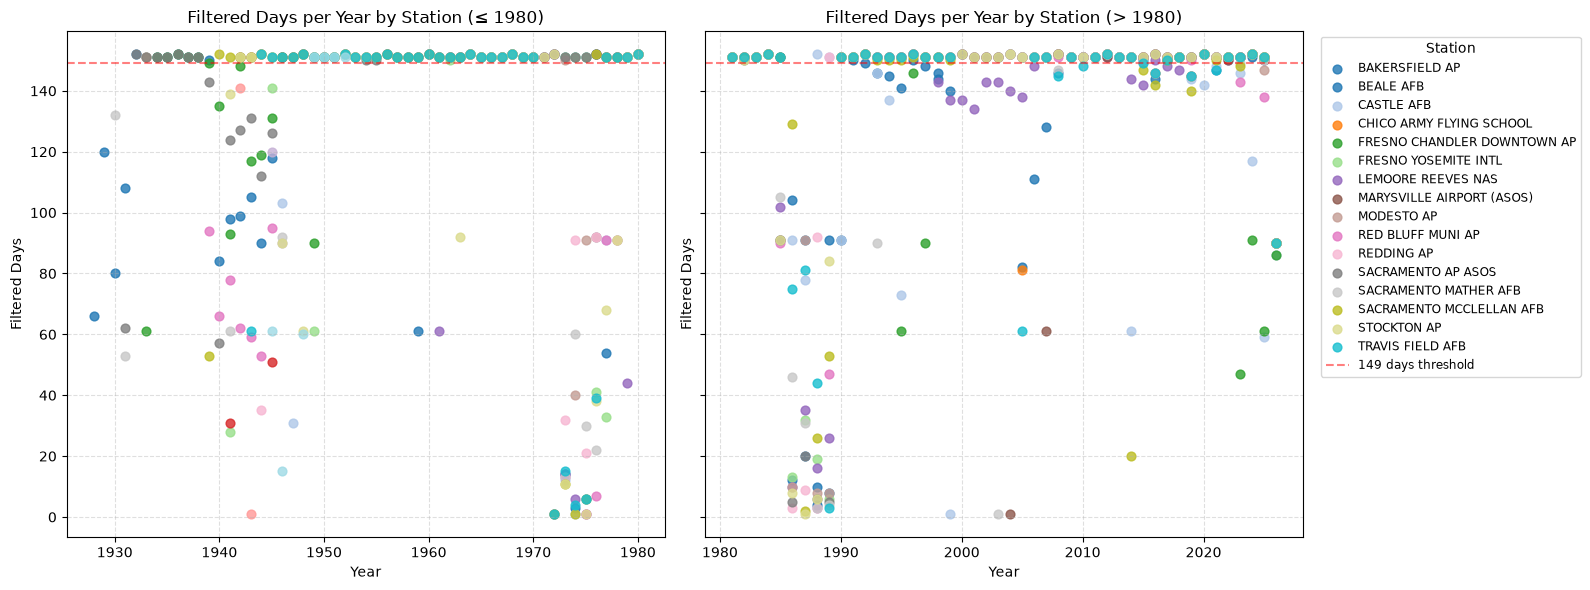

In [14]:
# plot the 'fog' days per year for the outliers for each station
# doing this in order to see where outlier years are
plot_stations = [st for st in stations_pre1970 if st in filtered_days_year['STATION'].unique()]
colors = plt.cm.tab20(np.linspace(0, 1, len(plot_stations)))
color_map = dict(zip(plot_stations, colors))

# Make sure to only plot for stations with data back to at least 1970
filtered_pre1970 = filtered_days_year[filtered_days_year['STATION'].isin(plot_stations)]

# Create a scatter plot for fog days per year for each station
# Data is separated into two subplots: one for years ≤ 1980 and another for years > 1980.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in plot_stations:
    station_df = filtered_pre1970[filtered_pre1970['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Filtered Days per Year by Station (≤ 1980)')
axes[1].set_title('Filtered Days per Year by Station (> 1980)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Filtered Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')


axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

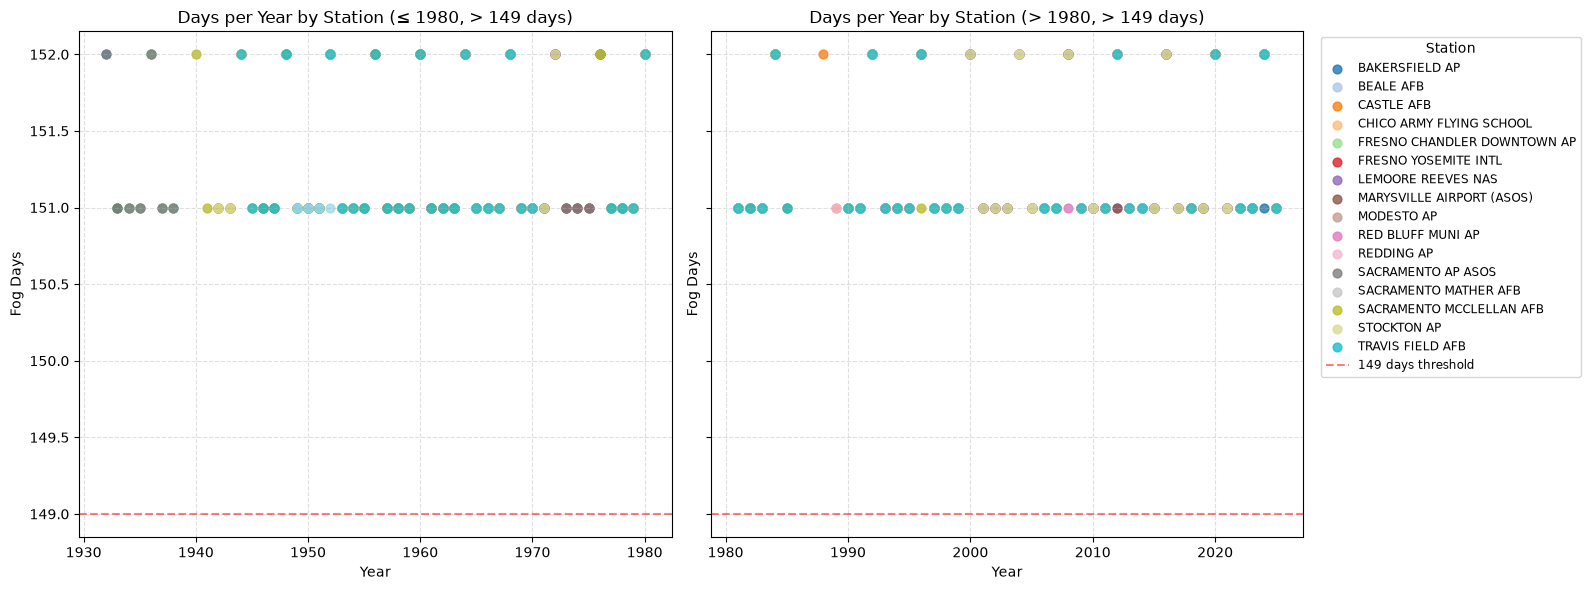

Stations with > 149 days: 19
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'LEMOORE REEVES NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'WILLIAMS CAA AIRPORT']


In [15]:
# Remove stations with less than or only 149 days counted
filtered_days_year_filtered = filtered_days_year[filtered_days_year['filtered_days'] > 150]

# Get the filtered list of stations
filtered_plot_stations = [st for st in plot_stations if st in filtered_days_year_filtered['STATION'].unique()]

# Create color map for filtered stations
colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# Filter fog data for pre-1970 stations with > 355 fog days
filtered_pre1970_filtered = filtered_days_year_filtered[filtered_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for station in filtered_plot_stations:
    station_df = filtered_pre1970_filtered[filtered_pre1970_filtered['STATION'] == station].sort_values('year')
    pre_df = station_df[station_df['year'] <= 1980]
    post_df = station_df[station_df['year'] > 1980]

    if not pre_df.empty:
        axes[0].scatter(
            pre_df['year'],
            pre_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

    if not post_df.empty:
        axes[1].scatter(
            post_df['year'],
            post_df['filtered_days'],
            s=40,
            color=color_map_filtered[station],
            alpha=0.8,
            label=station
        )

axes[0].set_title('Days per Year by Station (≤ 1980, > 149 days)')
axes[1].set_title('Days per Year by Station (> 1980, > 149 days)')

for ax in axes:
    ax.set_xlabel('Year')
    ax.set_ylabel('Fog Days')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(y=149, color='red', linestyle='--', alpha=0.5, label='149 days threshold')

axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

print(f"Stations with > 149 days: {len(filtered_plot_stations)}")
print(filtered_plot_stations)

In [16]:
# # Remove stations with less than or only 211 days counted
# filtered_days_year_filtered = filtered_days_year[filtered_days_year['filtered_days'] > 211]

# # Get the filtered list of stations
# filtered_plot_stations = [st for st in plot_stations if st in filtered_days_year_filtered['STATION'].unique()]

# # Create color map for filtered stations
# colors_filtered = plt.cm.tab20(np.linspace(0, 1, len(filtered_plot_stations)))
# color_map_filtered = dict(zip(filtered_plot_stations, colors_filtered))

# # Filter fog data for pre-1970 stations with > 355 fog days
# filtered_pre1970_filtered = filtered_days_year_filtered[filtered_days_year_filtered['STATION'].isin(filtered_plot_stations)]

# # Create the plot
# fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# for station in filtered_plot_stations:
#     station_df = filtered_pre1970_filtered[filtered_pre1970_filtered['STATION'] == station].sort_values('year')
#     pre_df = station_df[station_df['year'] <= 1980]
#     post_df = station_df[station_df['year'] > 1980]

#     if not pre_df.empty:
#         axes[0].scatter(
#             pre_df['year'],
#             pre_df['filtered_days'],
#             s=40,
#             color=color_map_filtered[station],
#             alpha=0.8,
#             label=station
#         )

#     if not post_df.empty:
#         axes[1].scatter(
#             post_df['year'],
#             post_df['filtered_days'],
#             s=40,
#             color=color_map_filtered[station],
#             alpha=0.8,
#             label=station
#         )

# axes[0].set_title('Days per Year by Station (≤ 1980, > 211 days)')
# axes[1].set_title('Days per Year by Station (> 1980, > 211 days)')

# for ax in axes:
#     ax.set_xlabel('Year')
#     ax.set_ylabel('Fog Days')
#     ax.grid(True, linestyle='--', alpha=0.4)
#     ax.axhline(y=211, color='red', linestyle='--', alpha=0.5, label='211 days threshold')

# axes[1].legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
# plt.tight_layout()
# plt.show()

# print(f"Stations with > 211 days: {len(filtered_plot_stations)}")
# print(filtered_plot_stations)

In [17]:
# Remove stations with 149 or fewer days counted
fog_days_year_no_outliers = filtered_days_year[filtered_days_year["filtered_days"] > 149].copy()

# Get the valid station-year combinations for merging
valid_station_years = fog_days_year_no_outliers[["STATION", "year"]]
CV_fog_rows_no_outliers = CV_filtered_rows.merge(valid_station_years, on=["STATION", "year"], how="inner")

# print to check
print("Station-years kept:", fog_days_year_no_outliers.shape[0])
print("CV_fog_rows_no_outliers:", CV_fog_rows_no_outliers.shape)

Station-years kept: 973
CV_fog_rows_no_outliers: (3978541, 19)


In [ ]:
# Filter rows from the narrowed dataframe with HourlyVisibility < 1.000
low_vis_rows = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 0.403]
low_vis_rows_1km = CV_fog_rows_no_outliers[CV_fog_rows_no_outliers["HourlyVisibility"] < 1.000]

print("CV_fog_rows_no_outliers with HourlyVisibility < 0.403:", low_vis_rows.shape)
print("CV_fog_rows_no_outliers with HourlyVisibility < 1.000:", low_vis_rows_1km.shape)

CV_fog_rows_no_outliers with HourlyVisibility < 0.403: (165251, 19)
CV_fog_rows_no_outliers with HourlyVisibility < 1.000: (221673, 19)


In [ ]:
# add a new dataframe to count the number of low visibility fog days per year per station
# with year, month, and day as unique identifiers to avoid double counting
low_vis_fog_days_year = (
    low_vis_rows
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

low_vis_fog_days_year_1km = (
    low_vis_rows_1km
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    .groupby(['STATION', 'year'], as_index=False)
    .size()
    .rename(columns={'size': 'fog_days'})
    .sort_values(['STATION', 'year'])
)

In [20]:
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts = low_vis_fog_days_year.groupby("STATION")["year"].nunique()
stations_with_30_years = station_year_counts[station_year_counts >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered = low_vis_fog_days_year[
    low_vis_fog_days_year["STATION"].isin(stations_with_30_years)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years))
print("Filtered low_vis_fog_days_year rows:", low_vis_fog_days_year_filtered.shape)

# -----
# print the number of unique years for each station in low_vis_fog_days_year
station_year_counts_1km = low_vis_fog_days_year_1km.groupby("STATION")["year"].nunique()
stations_with_30_years_1km = station_year_counts_1km[station_year_counts_1km >= 30].index

# filter low_vis_fog_days_year to only include stations with at least 30 years of data
low_vis_fog_days_year_filtered_1km = low_vis_fog_days_year_1km[
    low_vis_fog_days_year_1km["STATION"].isin(stations_with_30_years_1km)
].copy()

# print to check
print("Stations kept:", len(stations_with_30_years_1km))
print("Filtered low_vis_fog_days_year_1km rows:", low_vis_fog_days_year_filtered_1km.shape)

Stations kept: 14
Filtered low_vis_fog_days_year rows: (785, 3)
Stations kept: 14
Filtered low_vis_fog_days_year_1km rows: (785, 3)


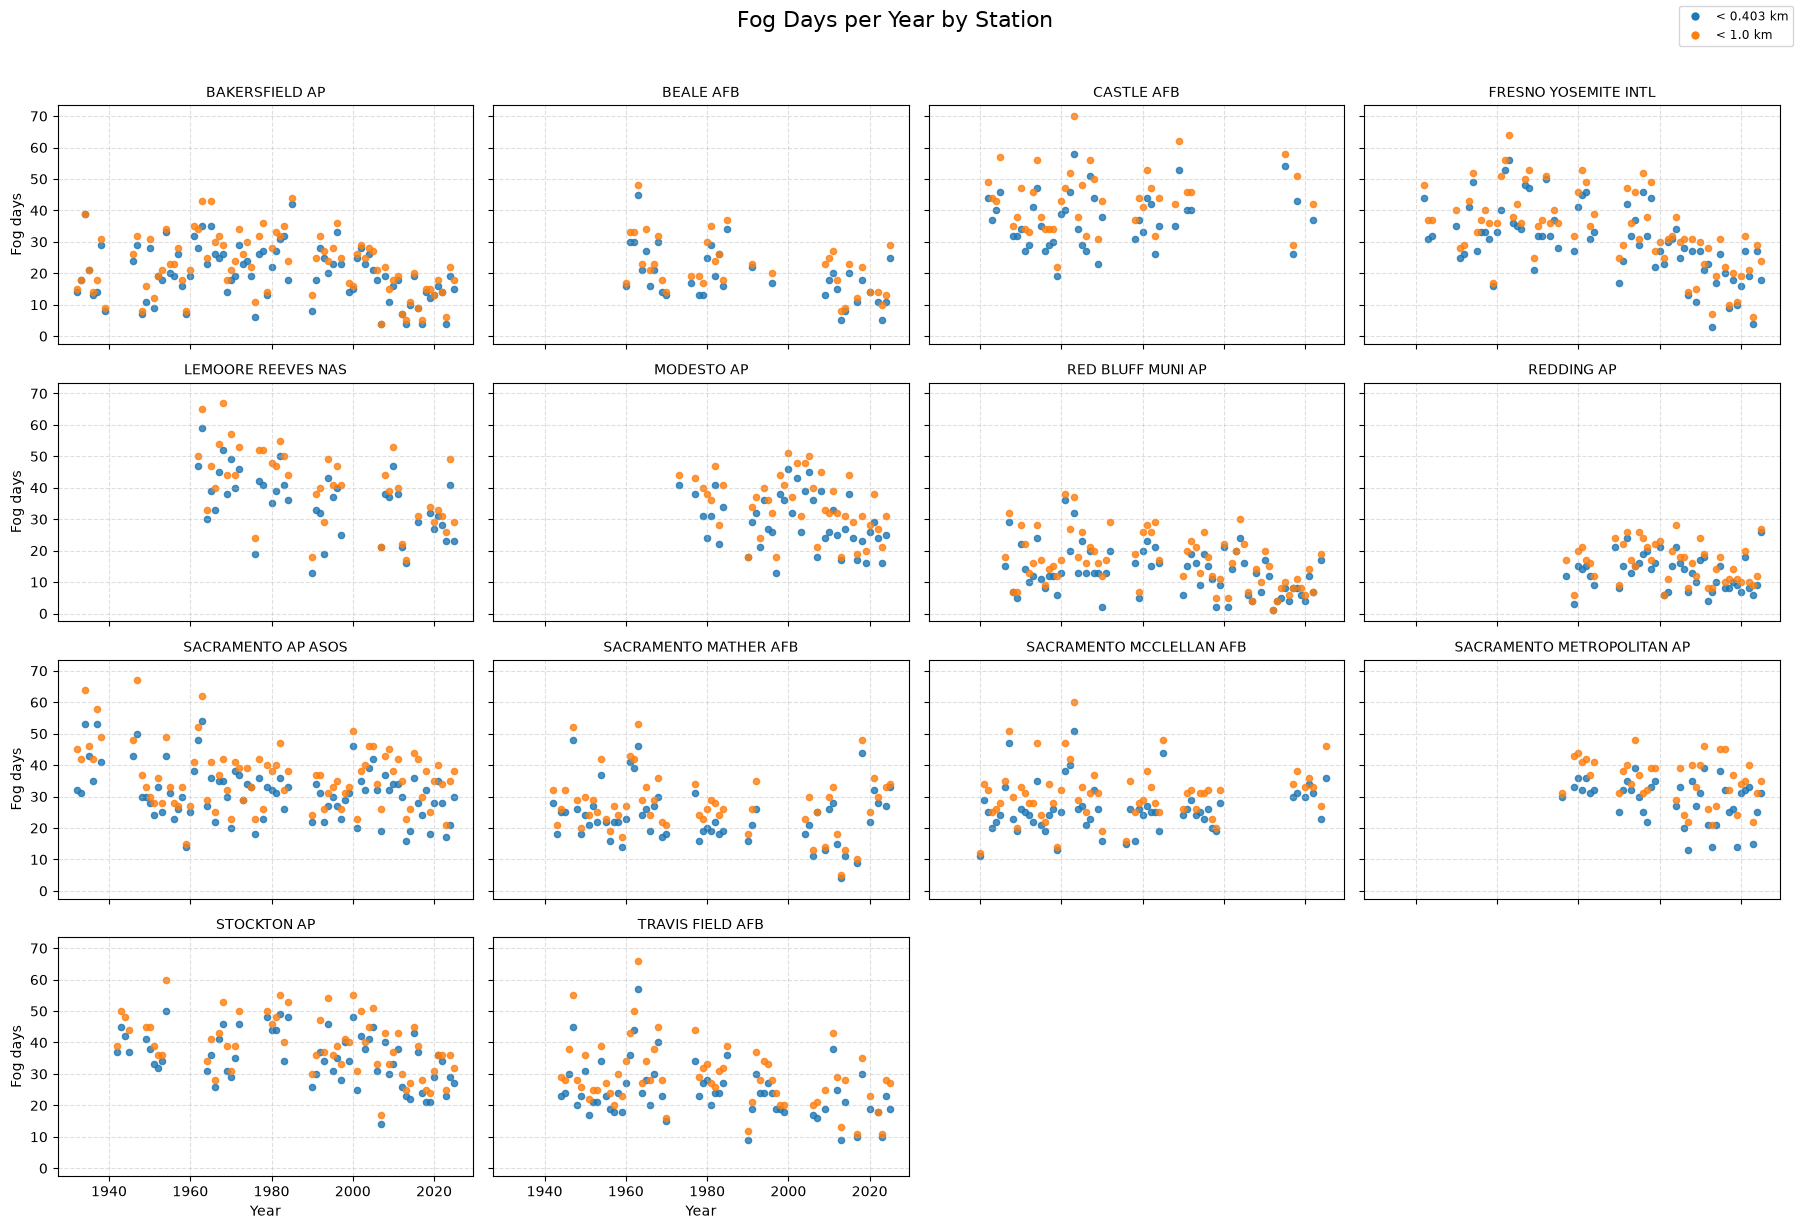

In [21]:
stations = sorted(
    set(low_vis_fog_days_year_filtered["STATION"])
    | set(low_vis_fog_days_year_filtered_1km["STATION"])
)

n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    df_h = low_vis_fog_days_year_filtered[
        low_vis_fog_days_year_filtered["STATION"] == station
    ].sort_values("year")
    df_1km = low_vis_fog_days_year_filtered_1km[
        low_vis_fog_days_year_filtered_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"],
            df_h["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:blue",
            label="< 0.403 km"
        )
    if not df_1km.empty:
        ax.scatter(
            df_1km["year"],
            df_1km["fog_days"],
            s=20,
            alpha=0.8,
            color="tab:orange",
            label="< 1.0 km"
        )

    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=7),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:orange", markersize=7),
]
fig.legend(handles, ["< 0.403 km", "< 1.0 km"], loc="upper right", fontsize="small")

fig.suptitle("Fog Days per Year by Station", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

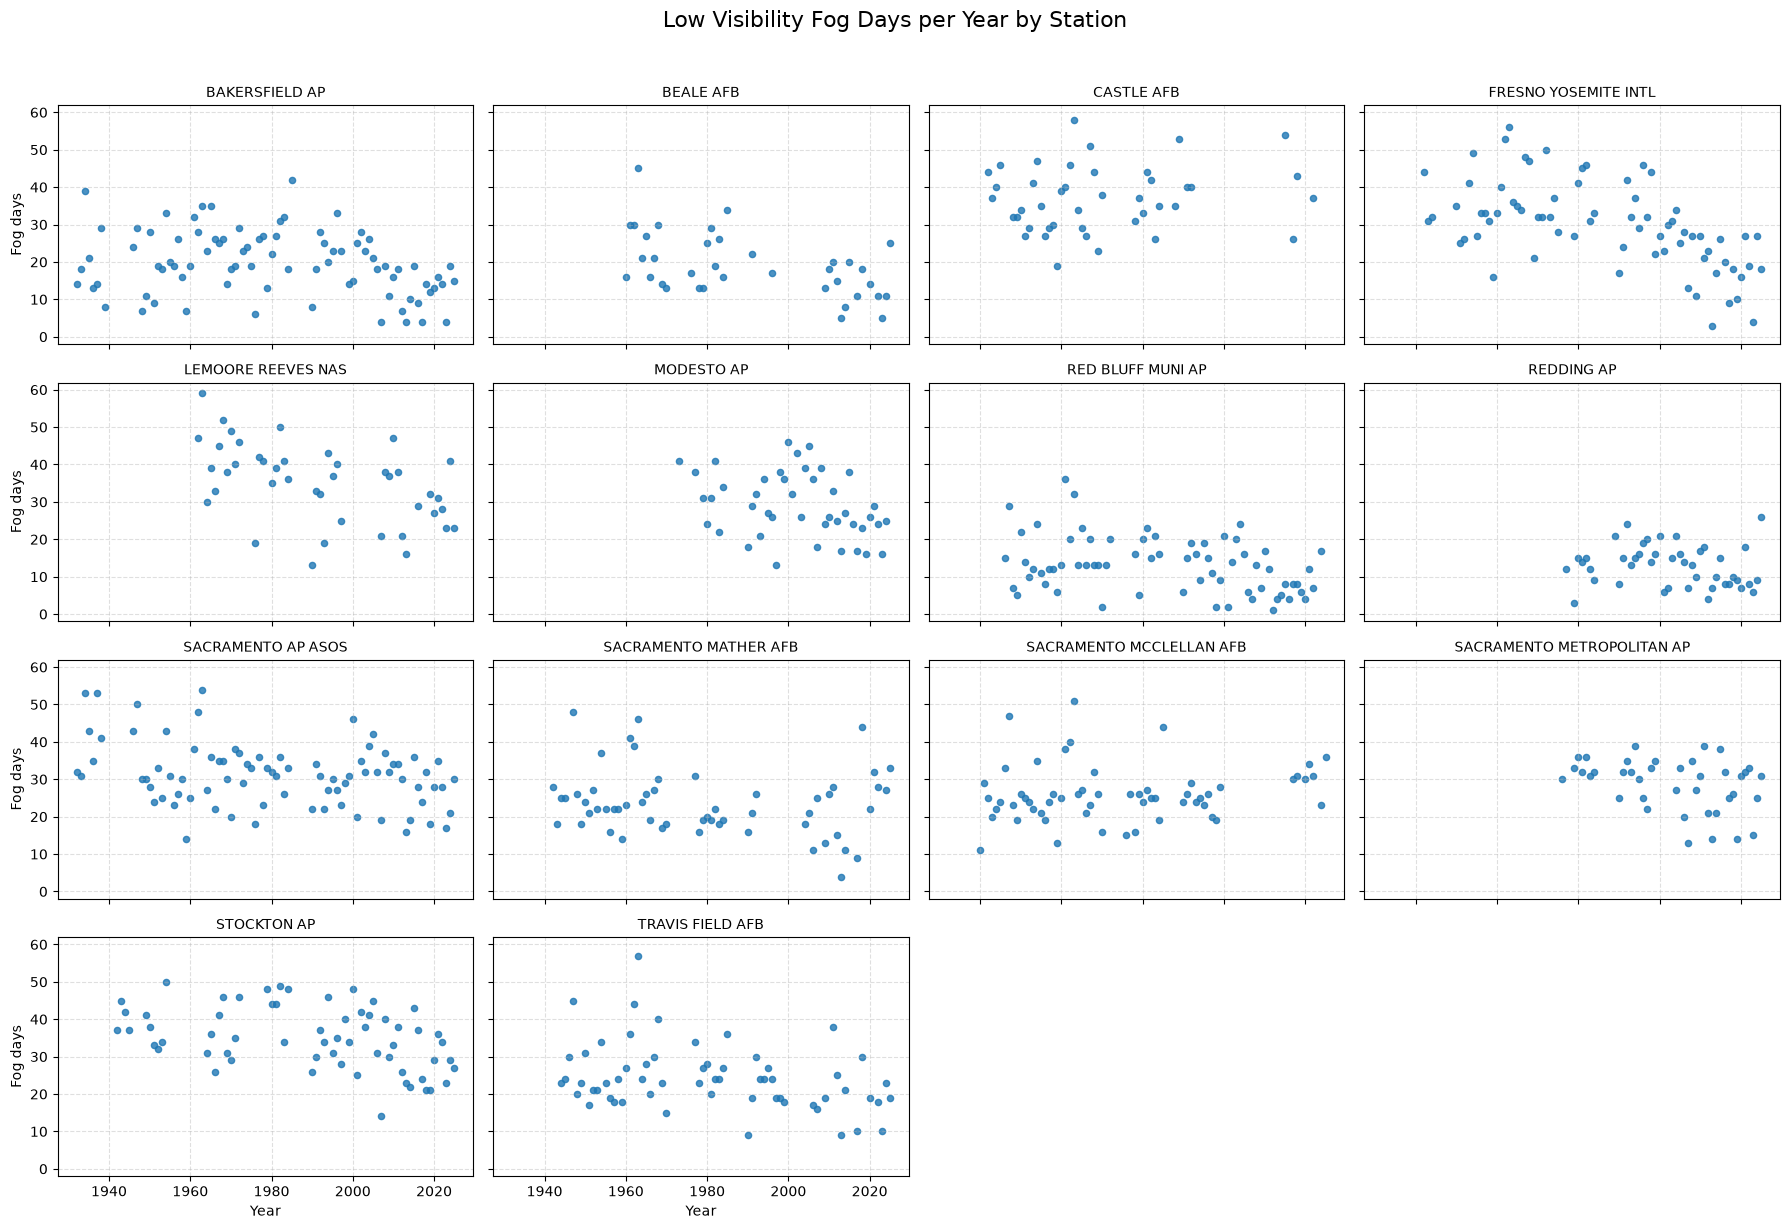

In [22]:
# plot the fog days per year for the filtered stations
stations = low_vis_fog_days_year_filtered['STATION'].unique()
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

# set up the plot:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

# plotting for individual stations:
for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered['STATION'] == station]
    ax.scatter(station_df['year'], station_df['fog_days'], s=20, alpha=0.8)
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx % ncols == 0:
        ax.set_ylabel('Fog days')
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel('Year')

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle('Low Visibility Fog Days per Year by Station', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Filter for low visibility fog days after 1980
post1980_low_vis = low_vis_fog_days_year_filtered[low_vis_fog_days_year_filtered["year"] >= 1980].copy()

trend_stats_low_vis_post1980 = []

for station, station_df in post1980_low_vis.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980 = pd.DataFrame(trend_stats_low_vis_post1980).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980 = trend_stats_low_vis_post1980[trend_stats_low_vis_post1980["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980)}")
print(significant_low_vis_post1980[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980 = (
    post1980_low_vis
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980 = smf.ols("fog_days ~ year", data=annual_low_vis_post1980).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.586052  0.097954   
0               BAKERSFIELD AP     41      1980      2025 -0.413335  0.081580   
12                 STOCKTON AP     41      1980      2025 -0.337277  0.092439   
6            RED BLUFF MUNI AP     39      1980      2024 -0.264745  0.074327   
1                    BEALE AFB     22      1980      2025 -0.294417  0.079436   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.183439  0.082945   
13            TRAVIS FIELD AFB     30      1980      2025 -0.157279  0.087486   
7                   REDDING AP     42      1980      2025 -0.108758  0.062793   
10    SACRAMENTO MCCLELLAN AFB     23      1980      2025  0.124195  0.075380   
4           LEMOORE REEVES NAS     28      1980      2025 -0.188149  0.117240   
5                   MODESTO AP     40      1980

In [24]:
# Filter for low visibility fog days after 1980
post1980_low_vis_1km = low_vis_fog_days_year_filtered_1km[low_vis_fog_days_year_filtered_1km["year"] >= 1980].copy()

trend_stats_low_vis_post1980_1km = []

for station, station_df in post1980_low_vis_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_days ~ year", data=station_df).fit()

    trend_stats_low_vis_post1980_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_low_vis_post1980_1km = pd.DataFrame(trend_stats_low_vis_post1980_1km).sort_values("p_value")

print("Post-1980 low-visibility fog-day trend statistics by station:")
print(trend_stats_low_vis_post1980_1km[
    ["STATION", "n_obs", "min_year", "max_year", "slope", "slope_se", "p_value", "r_squared", "trend_significant"]
].head(20))

significant_low_vis_post1980_1km = trend_stats_low_vis_post1980_1km[trend_stats_low_vis_post1980_1km["trend_significant"]]
print(f"\nStations with significant post-1980 low-visibility fog-day trends: {len(significant_low_vis_post1980_1km)}")
print(significant_low_vis_post1980_1km[
    ["STATION", "n_obs", "slope", "p_value", "r_squared"]
])

annual_low_vis_post1980_1km = (
    post1980_low_vis_1km
    .groupby("year", as_index=False)["fog_days"]
    .sum()
)

model_annual_low_vis_post1980_1km = smf.ols("fog_days ~ year", data=annual_low_vis_post1980_1km).fit()

print("\nAnnual aggregated post-1980 low-visibility fog-day trend summary:")
print(model_annual_low_vis_post1980_1km.summary())

Post-1980 low-visibility fog-day trend statistics by station:
                       STATION  n_obs  min_year  max_year     slope  slope_se  \
3         FRESNO YOSEMITE INTL     41      1980      2025 -0.660703  0.104010   
0               BAKERSFIELD AP     41      1980      2025 -0.491368  0.081271   
6            RED BLUFF MUNI AP     39      1980      2024 -0.387217  0.083805   
12                 STOCKTON AP     41      1980      2025 -0.394927  0.096638   
1                    BEALE AFB     22      1980      2025 -0.298109  0.089178   
4           LEMOORE REEVES NAS     28      1980      2025 -0.331053  0.125770   
11  SACRAMENTO METROPOLITAN AP     37      1980      2025 -0.188173  0.083872   
7                   REDDING AP     42      1980      2025 -0.150770  0.069783   
13            TRAVIS FIELD AFB     30      1980      2025 -0.181122  0.101168   
5                   MODESTO AP     40      1980      2024 -0.204019  0.116186   
10    SACRAMENTO MCCLELLAN AFB     23      1980

In [25]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980 = significant_low_vis_post1980.loc[
    significant_low_vis_post1980["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility fog-day trend stations:")
print(stations_significant_low_vis_post1980)

Significant post-1980 low-visibility fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'STOCKTON AP', 'RED BLUFF MUNI AP', 'BEALE AFB', 'SACRAMENTO METROPOLITAN AP']


In [26]:
# make a list of stations with significant trends for fog days after 1980
stations_significant_low_vis_post1980_1km = significant_low_vis_post1980_1km.loc[
    significant_low_vis_post1980_1km["trend_significant"], "STATION"
].tolist()

print("Significant post-1980 low-visibility (<1km) fog-day trend stations:")
print(stations_significant_low_vis_post1980_1km)

Significant post-1980 low-visibility (<1km) fog-day trend stations:
['FRESNO YOSEMITE INTL', 'BAKERSFIELD AP', 'RED BLUFF MUNI AP', 'STOCKTON AP', 'BEALE AFB', 'LEMOORE REEVES NAS', 'SACRAMENTO METROPOLITAN AP', 'REDDING AP']


In [ ]:
stations = stations_significant_low_vis_post1980

post1980_h = low_vis_fog_days_year_filtered[
    low_vis_fog_days_year_filtered["year"] >= 1980
]
post1980_1km = low_vis_fog_days_year_filtered_1km[
    low_vis_fog_days_year_filtered_1km["year"] >= 1980
]

In [ ]:
# Plot post-1980 scatterplots per station showing <0.403 km and <1.0 km points.
# If only one threshold has a confirmed trend for a station, plot only that threshold.
stations_h_sig = set(stations_significant_low_vis_post1980)      # <0.403 km significant
stations_1km_sig = set(stations_significant_low_vis_post1980_1km)  # <1.0 km significant

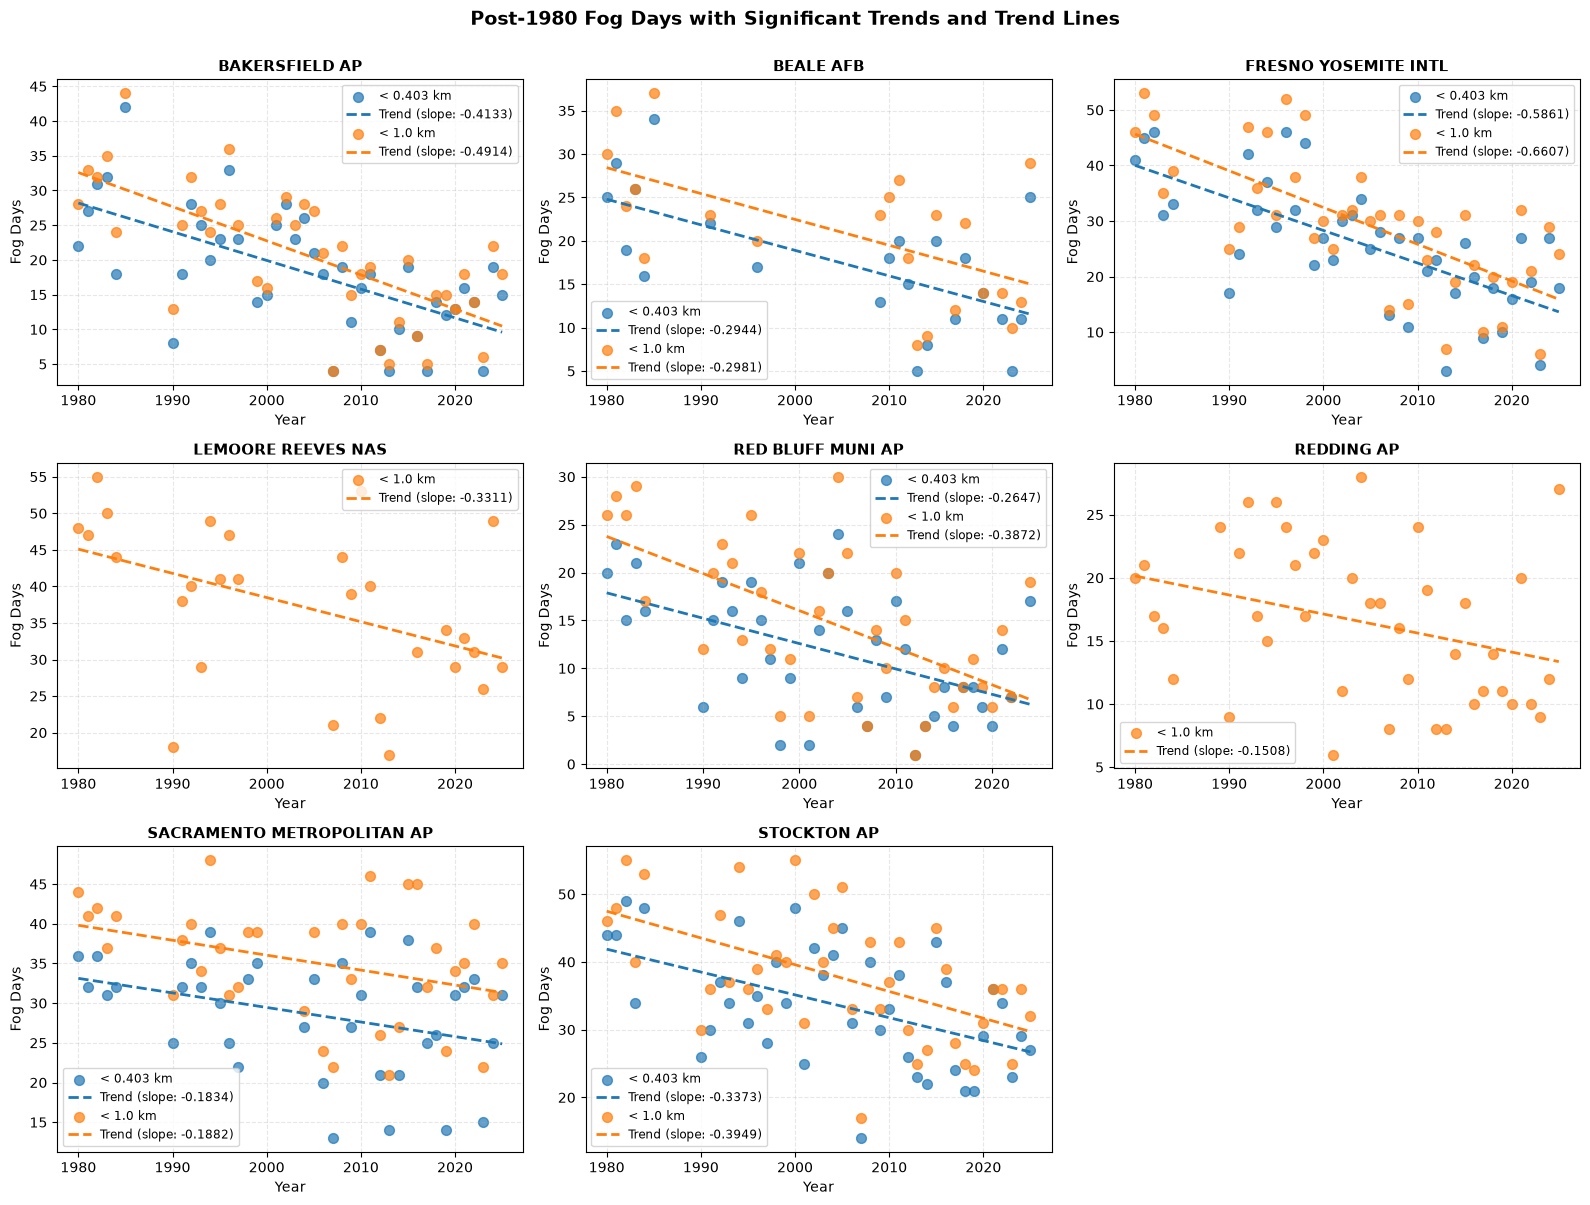

In [29]:
# Create scatterplots with trend lines for stations with significant trends
stations_to_plot = sorted(stations_h_sig | stations_1km_sig)
n_stations = len(stations_to_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, station in enumerate(stations_to_plot):
    ax = axes[idx]
    sig_h = station in stations_h_sig
    sig_1km = station in stations_1km_sig
    
    df_h = post1980_h[post1980_h["STATION"] == station].sort_values("year")
    df_1km = post1980_1km[post1980_1km["STATION"] == station].sort_values("year")
    
    # Plot data and trend lines for significant thresholds
    if sig_h and not df_h.empty:
        ax.scatter(df_h["year"], df_h["fog_days"], s=50, color="tab:blue", alpha=0.7, label="< 0.403 km")
        model_h = smf.ols("fog_days ~ year", data=df_h).fit()
        slope_h = model_h.params["year"]
        trend_line_h = model_h.predict(df_h)
        ax.plot(df_h["year"], trend_line_h, color="tab:blue", linewidth=2, linestyle="--", 
                label=f"Trend (slope: {slope_h:.4f})")
    
    if sig_1km and not df_1km.empty:
        ax.scatter(df_1km["year"], df_1km["fog_days"], s=50, color="tab:orange", alpha=0.7, label="< 1.0 km")
        model_1km = smf.ols("fog_days ~ year", data=df_1km).fit()
        slope_1km = model_1km.params["year"]
        trend_line_1km = model_1km.predict(df_1km)
        ax.plot(df_1km["year"], trend_line_1km, color="tab:orange", linewidth=2, linestyle="--",
                label=f"Trend (slope: {slope_1km:.4f})")
    
    ax.set_title(station, fontsize=11, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog Days")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize="small", loc="best")

# Remove unused axes
for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Post-1980 Fog Days with Significant Trends and Trend Lines", 
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

Now we try the same for fog nights


In [53]:
# Define fog "night" as 18:00-17:59, assigned to the date when the night starts.
# Uses the already-filtered low-visibility fog rows.

# --- <0.403 km threshold ---
night_rows_h = low_vis_rows.copy()
night_rows_h["DATE"] = pd.to_datetime(night_rows_h["DATE"])
night_rows_h["date_only"] = night_rows_h["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis and only stations with at least 30 years of data
# night_rows_h = night_rows_h[night_rows_h["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_h = night_rows_h[night_rows_h["STATION"].isin(stations_with_30_years)].copy()

is_night_h = (night_rows_h["DATE"].dt.hour >= 18) | (night_rows_h["DATE"].dt.hour < 18)

night_rows_h["night_date"] = pd.NaT
night_rows_h.loc[night_rows_h["DATE"].dt.hour >= 18, "night_date"] = night_rows_h["date_only"]
night_rows_h.loc[night_rows_h["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_h["date_only"] - pd.Timedelta(days=1)
)

night_rows_h = night_rows_h[is_night_h].copy()
night_rows_h["night_year"] = night_rows_h["night_date"].dt.year

fog_nights_year_station = (
    night_rows_h.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights = (
    fog_nights_year_station.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("Fog nights per station-year (<0.403 km):")
print(fog_nights_year_station.head())
print("\nAnnual fog nights (<0.403 km):")
print(annual_fog_nights.head())


# --- <1.0 km threshold (optional parallel series) ---
night_rows_1km = low_vis_rows_1km.copy()
night_rows_1km["DATE"] = pd.to_datetime(night_rows_1km["DATE"])
night_rows_1km["date_only"] = night_rows_1km["DATE"].dt.normalize()
# only use years >= 1980 for the night analysis
# night_rows_1km = night_rows_1km[night_rows_1km["year"] >= 1980].copy()
# only keep stations with at least 30 years of data since 1980
night_rows_1km = night_rows_1km[night_rows_1km["STATION"].isin(stations_with_30_years)].copy()

is_night_1km = (night_rows_1km["DATE"].dt.hour >= 18) | (night_rows_1km["DATE"].dt.hour < 18)

night_rows_1km["night_date"] = pd.NaT
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour >= 18, "night_date"] = night_rows_1km["date_only"]
night_rows_1km.loc[night_rows_1km["DATE"].dt.hour < 18, "night_date"] = (
    night_rows_1km["date_only"] - pd.Timedelta(days=1)
)

night_rows_1km = night_rows_1km[is_night_1km].copy()
night_rows_1km["night_year"] = night_rows_1km["night_date"].dt.year

fog_nights_year_station_1km = (
    night_rows_1km.drop_duplicates(["STATION", "night_date"])
    .groupby(["STATION", "night_year"], as_index=False)
    .size()
    .rename(columns={"size": "fog_nights", "night_year": "year"})
    .sort_values(["STATION", "year"])
)

annual_fog_nights_1km = (
    fog_nights_year_station_1km.groupby("year", as_index=False)["fog_nights"]
    .sum()
    .sort_values("year")
)

print("\nFog nights per station-year (<1.0 km):")
print(fog_nights_year_station_1km.head())
print("\nAnnual fog nights (<1.0 km):")
print(annual_fog_nights_1km.head())

Fog nights per station-year (<0.403 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1931           1
1  BAKERSFIELD AP  1932          13
2  BAKERSFIELD AP  1933          18
3  BAKERSFIELD AP  1934          38
4  BAKERSFIELD AP  1935          18

Annual fog nights (<0.403 km):
   year  fog_nights
0  1931           2
1  1932          44
2  1933          48
3  1934          92
4  1935          59

Fog nights per station-year (<1.0 km):
          STATION  year  fog_nights
0  BAKERSFIELD AP  1931           1
1  BAKERSFIELD AP  1932          14
2  BAKERSFIELD AP  1933          18
3  BAKERSFIELD AP  1934          39
4  BAKERSFIELD AP  1935          18

Annual fog nights (<1.0 km):
   year  fog_nights
0  1931           2
1  1932          59
2  1933          58
3  1934         105
4  1935          62


In [ ]:
# Determine station-level fog-night trends since 1980
# and plot only significant trends (<0.05 p-value)

trend_stats_nights_h = []
for station, station_df in fog_nights_year_station.groupby("STATION"):
    station_df = station_df.sort_values("year")
    station_df = station_df[station_df["year"] >= 1980]
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_h = pd.DataFrame(trend_stats_nights_h).sort_values("p_value")
significant_nights_h = trend_stats_nights_h[trend_stats_nights_h["trend_significant"]].copy()

print("Significant fog-night trends (<0.403 km):")
print(significant_nights_h[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

# Optional parallel analysis for <1.0 km
trend_stats_nights_1km = []
for station, station_df in fog_nights_year_station_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue

    model = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model.params["year"],
        "intercept": model.params["Intercept"],
        "r_squared": model.rsquared,
        "p_value": model.pvalues["year"],
        "slope_se": model.bse["year"],
        "trend_significant": model.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km = pd.DataFrame(trend_stats_nights_1km).sort_values("p_value")
significant_nights_1km = trend_stats_nights_1km[trend_stats_nights_1km["trend_significant"]].copy()

print("\nSignificant fog-night trends (<1.0 km):")
print(significant_nights_1km[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

Significant fog-night trends (<0.403 km):
                       STATION  n_obs     slope   p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.528048  0.000002   0.445539
0               BAKERSFIELD AP     42 -0.379686  0.000047   0.342608
6            RED BLUFF MUNI AP     39 -0.253257  0.001270   0.247560
1                    BEALE AFB     22 -0.276936  0.001427   0.405951
11  SACRAMENTO METROPOLITAN AP     37 -0.216455  0.012078   0.166841
12                 STOCKTON AP     42 -0.267953  0.016357   0.135749
5                   MODESTO AP     40 -0.201722  0.046120   0.100608

Significant fog-night trends (<1.0 km):
                 STATION  n_obs     slope   p_value  r_squared
3   FRESNO YOSEMITE INTL     72 -0.237155  0.000015   0.236259
13      TRAVIS FIELD AFB     60 -0.158404  0.002229   0.150063
6      RED BLUFF MUNI AP     70 -0.124337  0.002238   0.129255
1              BEALE AFB     36 -0.185269  0.003021   0.230814
5             MODESTO AP     43 -0.275630  0.00445

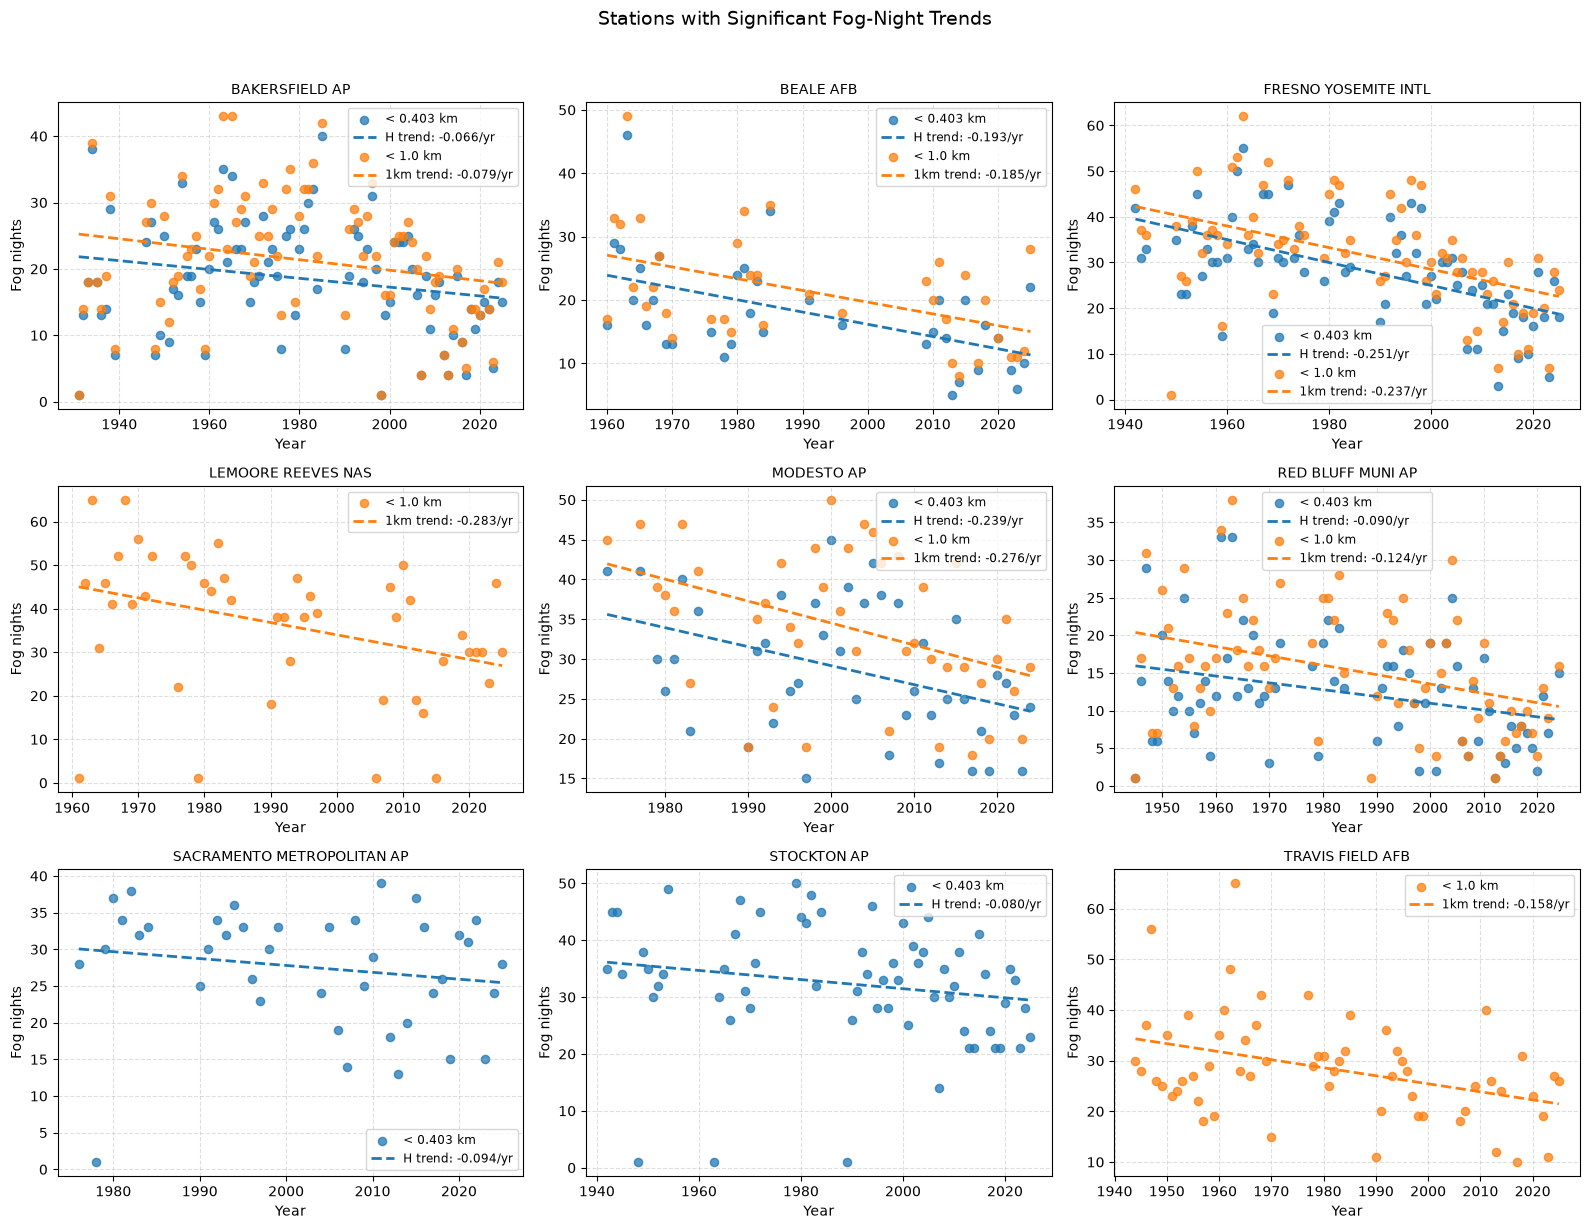

In [55]:
# Plot significant stations with trend lines since 1980 for fog nights (<0.403 km and <1.0 km)

stations_h_sig_nights = set(significant_nights_h["STATION"])
stations_1km_sig_nights = set(significant_nights_1km["STATION"])
stations_to_plot_nights = sorted(stations_h_sig_nights | stations_1km_sig_nights)

if len(stations_to_plot_nights) == 0:
    print("\nNo significant station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights):
        ax = axes[idx]

        df_h = fog_nights_year_station[fog_nights_year_station["STATION"] == station].sort_values("year")
        df_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights and not df_h.empty:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights and not df_1km.empty:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [56]:
# Fog-night trends starting in 1980 only, then plot only significant station trends

post1980_nights_h = fog_nights_year_station[fog_nights_year_station["year"] >= 1980].copy()
post1980_nights_1km = fog_nights_year_station_1km[fog_nights_year_station_1km["year"] >= 1980].copy()

trend_stats_nights_h_post1980 = []
for station, station_df in post1980_nights_h.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_h_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_h_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_h_1980.params["year"],
        "intercept": model_h_1980.params["Intercept"],
        "r_squared": model_h_1980.rsquared,
        "p_value": model_h_1980.pvalues["year"],
        "slope_se": model_h_1980.bse["year"],
        "trend_significant": model_h_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_h_post1980 = pd.DataFrame(trend_stats_nights_h_post1980).sort_values("p_value")
significant_nights_h_post1980 = trend_stats_nights_h_post1980[
    trend_stats_nights_h_post1980["trend_significant"]
].copy()

trend_stats_nights_1km_post1980 = []
for station, station_df in post1980_nights_1km.groupby("STATION"):
    station_df = station_df.sort_values("year")
    if len(station_df) < 3:
        continue
    model_1km_1980 = smf.ols("fog_nights ~ year", data=station_df).fit()
    trend_stats_nights_1km_post1980.append({
        "STATION": station,
        "n_obs": len(station_df),
        "min_year": station_df["year"].min(),
        "max_year": station_df["year"].max(),
        "slope": model_1km_1980.params["year"],
        "intercept": model_1km_1980.params["Intercept"],
        "r_squared": model_1km_1980.rsquared,
        "p_value": model_1km_1980.pvalues["year"],
        "slope_se": model_1km_1980.bse["year"],
        "trend_significant": model_1km_1980.pvalues["year"] < 0.05,
    })

trend_stats_nights_1km_post1980 = pd.DataFrame(trend_stats_nights_1km_post1980).sort_values("p_value")
significant_nights_1km_post1980 = trend_stats_nights_1km_post1980[
    trend_stats_nights_1km_post1980["trend_significant"]
].copy()

print("Significant post-1980 fog-night trends (<0.403 km):")
print(significant_nights_h_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])

print("\nSignificant post-1980 fog-night trends (<1.0 km):")
print(significant_nights_1km_post1980[["STATION", "n_obs", "slope", "p_value", "r_squared"]])


Significant post-1980 fog-night trends (<0.403 km):
                       STATION  n_obs     slope   p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.528048  0.000002   0.445539
0               BAKERSFIELD AP     42 -0.379686  0.000047   0.342608
6            RED BLUFF MUNI AP     39 -0.253257  0.001270   0.247560
1                    BEALE AFB     22 -0.276936  0.001427   0.405951
11  SACRAMENTO METROPOLITAN AP     37 -0.216455  0.012078   0.166841
12                 STOCKTON AP     42 -0.267953  0.016357   0.135749
5                   MODESTO AP     40 -0.201722  0.046120   0.100608

Significant post-1980 fog-night trends (<1.0 km):
                       STATION  n_obs     slope       p_value  r_squared
3         FRESNO YOSEMITE INTL     41 -0.605373  2.301672e-07   0.500690
0               BAKERSFIELD AP     42 -0.458413  3.873697e-06   0.416994
6            RED BLUFF MUNI AP     40 -0.326096  5.532941e-04   0.272332
1                    BEALE AFB     22 -0.283203  3.85

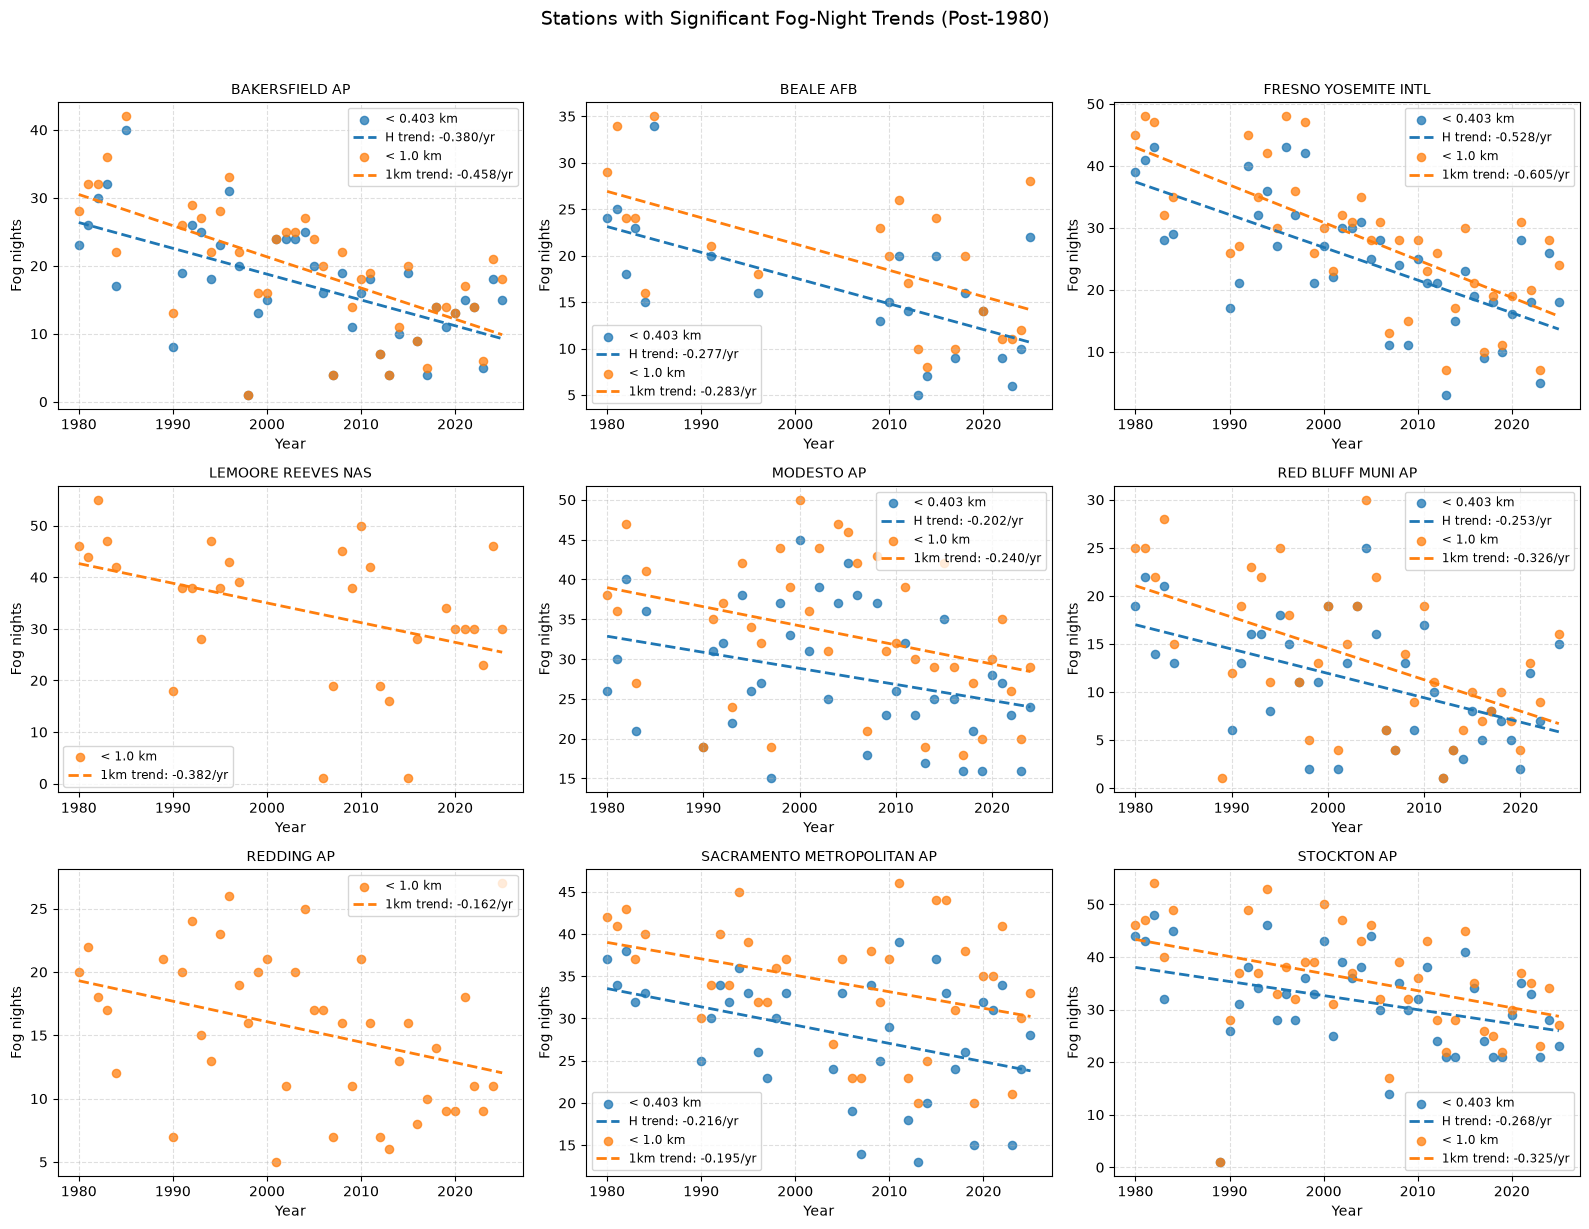

In [57]:

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])
stations_to_plot_nights_post1980 = sorted(stations_h_sig_nights_post1980 | stations_1km_sig_nights_post1980)

if len(stations_to_plot_nights_post1980) == 0:
    print("\nNo significant post-1980 station trends to plot.")
else:
    ncols = 3
    nrows = int(np.ceil(len(stations_to_plot_nights_post1980) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).reshape(-1)

    for idx, station in enumerate(stations_to_plot_nights_post1980):
        ax = axes[idx]

        df_h = post1980_nights_h[post1980_nights_h["STATION"] == station].sort_values("year")
        df_1km = post1980_nights_1km[post1980_nights_1km["STATION"] == station].sort_values("year")

        if station in stations_h_sig_nights_post1980 and not df_h.empty:
            model_h_1980 = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.scatter(df_h["year"], df_h["fog_nights"], s=35, color="tab:blue", alpha=0.75, label="< 0.403 km")
            ax.plot(
                df_h["year"],
                model_h_1980.predict(df_h),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"H trend: {model_h_1980.params['year']:.3f}/yr"
            )

        if station in stations_1km_sig_nights_post1980 and not df_1km.empty:
            model_1km_1980 = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.scatter(df_1km["year"], df_1km["fog_nights"], s=35, color="tab:orange", alpha=0.75, label="< 1.0 km")
            ax.plot(
                df_1km["year"],
                model_1km_1980.predict(df_1km),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"1km trend: {model_1km_1980.params['year']:.3f}/yr"
            )

        ax.set_title(station, fontsize=10)
        ax.set_xlabel("Year")
        ax.set_ylabel("Fog nights")
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(fontsize="small", loc="best")

    for ax in axes[len(stations_to_plot_nights_post1980):]:
        fig.delaxes(ax)

    fig.suptitle("Stations with Significant Fog-Night Trends (Post-1980)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [58]:
# Compare fog DAYS vs fog NIGHTS (post-1980) and their trend slopes/significance

# --- 1) Average measured fog days/nights per station ---
avg_h_days = post1980_h.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_h"}
)
avg_h_nights = post1980_nights_h.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_h"}
)

avg_1km_days = post1980_1km.groupby("STATION", as_index=False)["fog_days"].mean().rename(
    columns={"fog_days": "avg_fog_days_1km"}
)
avg_1km_nights = post1980_nights_1km.groupby("STATION", as_index=False)["fog_nights"].mean().rename(
    columns={"fog_nights": "avg_fog_nights_1km"}
)

# --- 2) Trend comparison tables (<0.403 km) ---
days_h = trend_stats_low_vis_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_h",
        "p_value": "p_days_h",
        "trend_significant": "sig_days_h",
        "n_obs": "n_days_h",
    }
)

nights_h = trend_stats_nights_h_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_h",
        "p_value": "p_nights_h",
        "trend_significant": "sig_nights_h",
        "n_obs": "n_nights_h",
    }
)

comparison_h = (
    days_h.merge(nights_h, on="STATION", how="outer")
    .merge(avg_h_days, on="STATION", how="left")
    .merge(avg_h_nights, on="STATION", how="left")
)

comparison_h["sig_category_h"] = np.select(
    [
        comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
        comparison_h["sig_days_h"].fillna(False) & ~comparison_h["sig_nights_h"].fillna(False),
        ~comparison_h["sig_days_h"].fillna(False) & comparison_h["sig_nights_h"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 3) Trend comparison tables (<1.0 km) ---
days_1km = trend_stats_low_vis_post1980_1km[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_days_1km",
        "p_value": "p_days_1km",
        "trend_significant": "sig_days_1km",
        "n_obs": "n_days_1km",
    }
)

nights_1km = trend_stats_nights_1km_post1980[
    ["STATION", "slope", "p_value", "trend_significant", "n_obs"]
].rename(
    columns={
        "slope": "slope_nights_1km",
        "p_value": "p_nights_1km",
        "trend_significant": "sig_nights_1km",
        "n_obs": "n_nights_1km",
    }
)

comparison_1km = (
    days_1km.merge(nights_1km, on="STATION", how="outer")
    .merge(avg_1km_days, on="STATION", how="left")
    .merge(avg_1km_nights, on="STATION", how="left")
)

comparison_1km["sig_category_1km"] = np.select(
    [
        comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
        comparison_1km["sig_days_1km"].fillna(False) & ~comparison_1km["sig_nights_1km"].fillna(False),
        ~comparison_1km["sig_days_1km"].fillna(False) & comparison_1km["sig_nights_1km"].fillna(False),
    ],
    ["both significant", "days only significant", "nights only significant"],
    default="neither significant",
)

# --- 4) Print compact outputs ---
print("=== <0.403 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_h.sort_values(["sig_category_h", "STATION"])[
        [
            "STATION",
            "avg_fog_days_h", "avg_fog_nights_h",
            "slope_days_h", "p_days_h", "sig_days_h",
            "slope_nights_h", "p_nights_h", "sig_nights_h",
            "sig_category_h",
        ]
    ]
)

print("\nCounts by significance category (<0.403 km):")
print(comparison_h["sig_category_h"].value_counts())

print("\n=== <1.0 km: Days vs Nights trend comparison (post-1980) ===")
print(
    comparison_1km.sort_values(["sig_category_1km", "STATION"])[
        [
            "STATION",
            "avg_fog_days_1km", "avg_fog_nights_1km",
            "slope_days_1km", "p_days_1km", "sig_days_1km",
            "slope_nights_1km", "p_nights_1km", "sig_nights_1km",
            "sig_category_1km",
        ]
    ]
)

print("\nCounts by significance category (<1.0 km):")
print(comparison_1km["sig_category_1km"].value_counts())

=== <0.403 km: Days vs Nights trend comparison (post-1980) ===
                       STATION  avg_fog_days_h  avg_fog_nights_h  \
0               BAKERSFIELD AP       18.243902         17.285714   
1                    BEALE AFB       17.363636         16.136364   
3         FRESNO YOSEMITE INTL       25.731707         24.512195   
6            RED BLUFF MUNI AP       11.692308         11.076923   
11  SACRAMENTO METROPOLITAN AP       28.594595         28.189189   
12                 STOCKTON AP       33.658537         31.571429   
2                   CASTLE AFB       39.076923         32.000000   
4           LEMOORE REEVES NAS       31.964286         28.566667   
7                   REDDING AP       13.238095         12.238095   
8           SACRAMENTO AP ASOS       29.219512         27.756098   
9        SACRAMENTO MATHER AFB       21.120000         19.115385   
10    SACRAMENTO MCCLELLAN AFB       27.086957         24.125000   
13            TRAVIS FIELD AFB       21.533333       

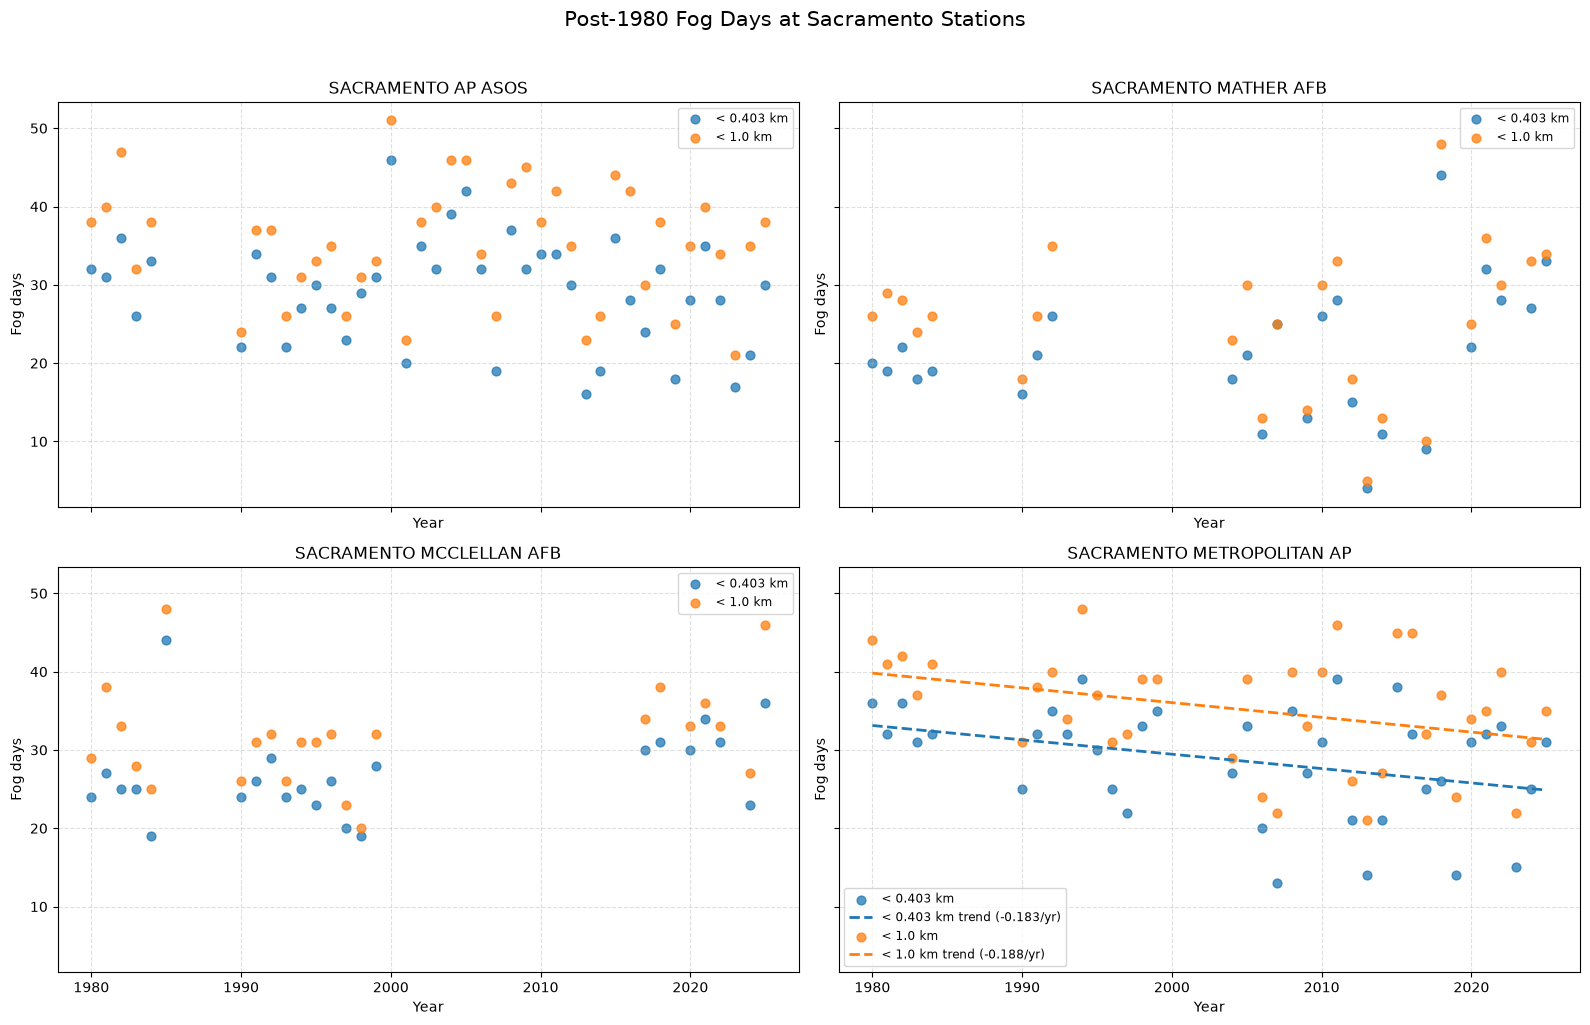

In [60]:
# Scatterplots of post-1980 fog days for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_stations = sorted(
    set(
        post1980_h.loc[
            post1980_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_1km.loc[
            post1980_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

sac_ncols = 2
sac_nrows = int(np.ceil(len(sacramento_stations) / sac_ncols))

fig, axes = plt.subplots(
    sac_nrows,
    sac_ncols,
    figsize=(16, sac_nrows * 5),
    sharex=True,
    sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, sac_station in enumerate(sacramento_stations):
    ax = axes[idx]

    df_h_sac = post1980_h[
        post1980_h["STATION"] == sac_station
    ].sort_values("year")

    df_1km_sac = post1980_1km[
        post1980_1km["STATION"] == sac_station
    ].sort_values("year")

    if not df_h_sac.empty:
        ax.scatter(
            df_h_sac["year"],
            df_h_sac["fog_days"],
            color="tab:blue",
            alpha=0.75,
            s=40,
            label="< 0.403 km"
        )

        model_h_sac = smf.ols("fog_days ~ year", data=df_h_sac).fit()
        if model_h_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_h_sac["year"],
                model_h_sac.predict(df_h_sac),
                color="tab:blue",
                linestyle="--",
                linewidth=2,
                label=f"< 0.403 km trend ({model_h_sac.params['year']:.3f}/yr)"
            )

    if not df_1km_sac.empty:
        ax.scatter(
            df_1km_sac["year"],
            df_1km_sac["fog_days"],
            color="tab:orange",
            alpha=0.75,
            s=40,
            label="< 1.0 km"
        )

        model_1km_sac = smf.ols("fog_days ~ year", data=df_1km_sac).fit()
        if model_1km_sac.pvalues["year"] < 0.05:
            ax.plot(
                df_1km_sac["year"],
                model_1km_sac.predict(df_1km_sac),
                color="tab:orange",
                linestyle="--",
                linewidth=2,
                label=f"< 1.0 km trend ({model_1km_sac.params['year']:.3f}/yr)"
            )

    ax.set_title(sac_station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog days")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Days at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()

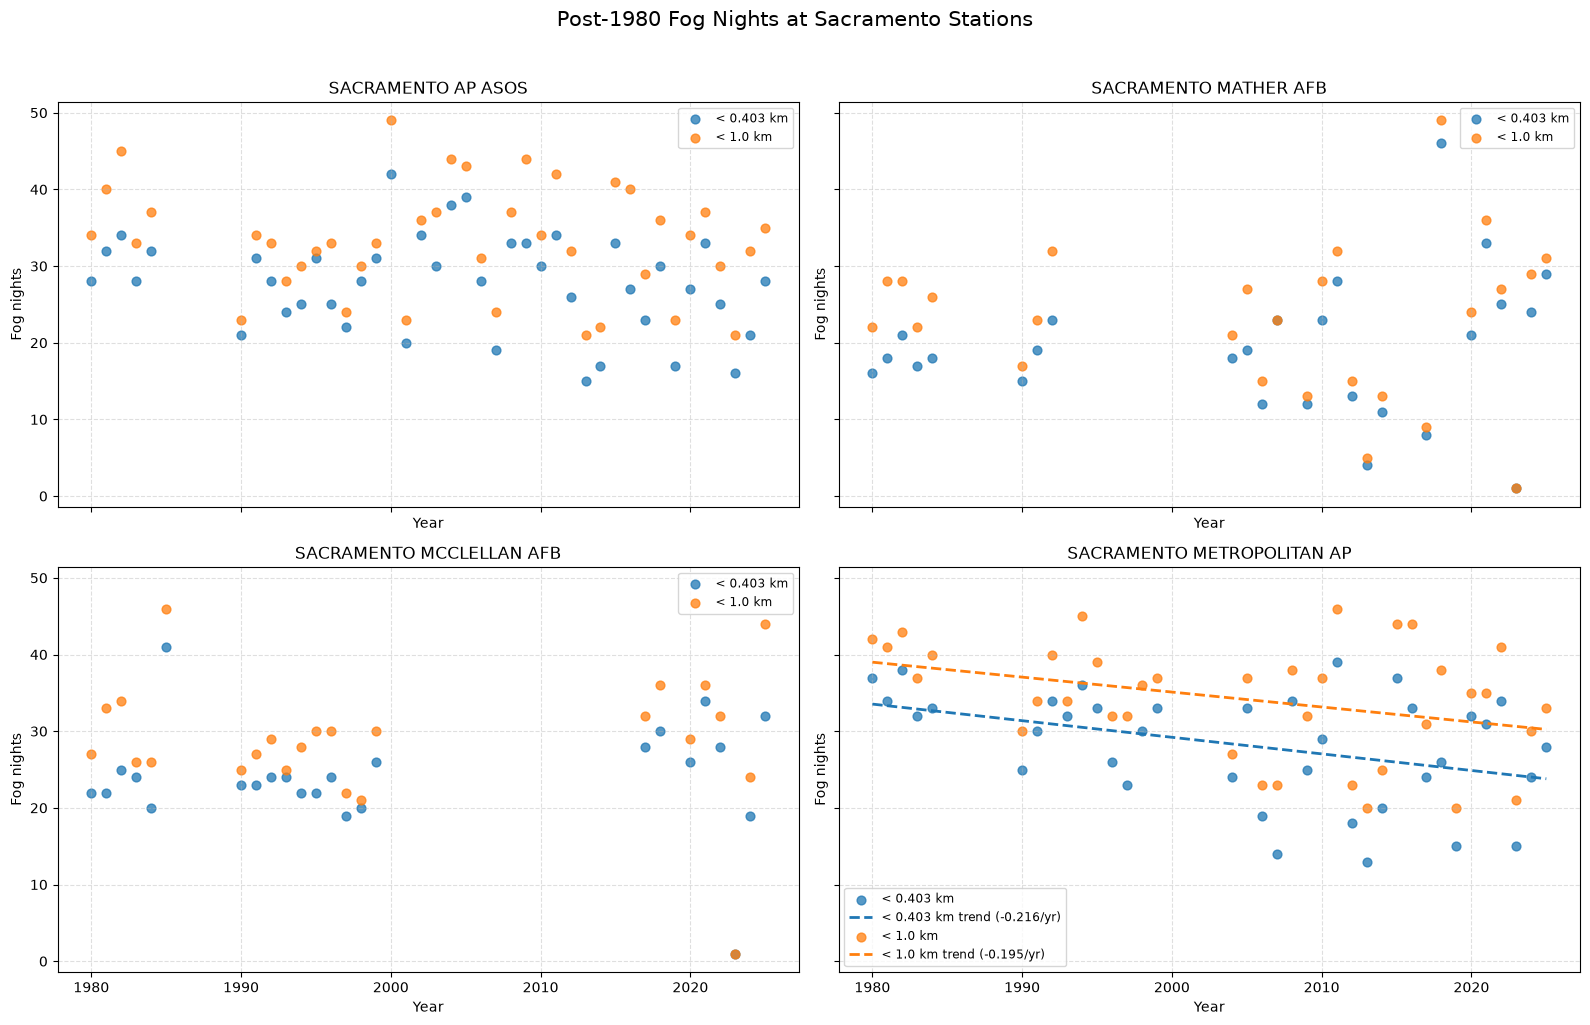

In [63]:
# Scatterplots of post-1980 fog nights for Sacramento stations.
# Trend lines are shown only for statistically significant trends (p < 0.05).

sacramento_night_stations = sorted(
    set(
        post1980_nights_h.loc[
            post1980_nights_h["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
    | set(
        post1980_nights_1km.loc[
            post1980_nights_1km["STATION"].str.contains("SACRAMENTO", case=False, na=False),
            "STATION"
        ]
    )
)

stations_h_sig_nights_post1980 = set(significant_nights_h_post1980["STATION"])
stations_1km_sig_nights_post1980 = set(significant_nights_1km_post1980["STATION"])

ncols = 2
nrows = int(np.ceil(len(sacramento_night_stations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(16, nrows * 5), sharex=True, sharey=True
)
axes = np.asarray(axes).reshape(-1)

for idx, station in enumerate(sacramento_night_stations):
    ax = axes[idx]

    df_h = post1980_nights_h[
        post1980_nights_h["STATION"] == station
    ].sort_values("year")

    df_1km = post1980_nights_1km[
        post1980_nights_1km["STATION"] == station
    ].sort_values("year")

    if not df_h.empty:
        ax.scatter(
            df_h["year"], df_h["fog_nights"],
            color="tab:blue", alpha=0.75, s=40,
            label="< 0.403 km"
        )

        if station in stations_h_sig_nights_post1980:
            model_h = smf.ols("fog_nights ~ year", data=df_h).fit()
            ax.plot(
                df_h["year"], model_h.predict(df_h),
                color="tab:blue", linestyle="--", linewidth=2,
                label=f"< 0.403 km trend ({model_h.params['year']:.3f}/yr)"
            )

    if not df_1km.empty:
        ax.scatter(
            df_1km["year"], df_1km["fog_nights"],
            color="tab:orange", alpha=0.75, s=40,
            label="< 1.0 km"
        )

        if station in stations_1km_sig_nights_post1980:
            model_1km = smf.ols("fog_nights ~ year", data=df_1km).fit()
            ax.plot(
                df_1km["year"], model_1km.predict(df_1km),
                color="tab:orange", linestyle="--", linewidth=2,
                label=f"< 1.0 km trend ({model_1km.params['year']:.3f}/yr)"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog nights")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize="small")

for ax in axes[len(sacramento_night_stations):]:
    fig.delaxes(ax)

fig.suptitle(
    "Post-1980 Fog Nights at Sacramento Stations",
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()